
  BITCOIN (BTC) vs S&P/BMV IPC (MEXICO) — IMPACT ANALYSIS

  Detected files:
    S&P/BMV IPC : ./S&P_BMV IPC Historical Data.csv
    Bitcoin     : /content/Bitcoin Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  BTC_Return  BMV_Return
2019-01-01     -0.0734      0.0564
2019-02-01      0.1104     -0.0265
2019-03-01      0.0749      0.0107
2019-04-01      0.2970      0.0304
2019-05-01      0.6085     -0.0414
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
            Count    Mean     Std     Min     25%     50%     75%     Max
BTC_Return   87.0  0.0503  0.1894 -0.3732 -0.0714  0.0246  0.1376  0.6085
BMV_Return   87.0  0.0066  0.0482 -0.1638 -0.0255  0.0095  0.0353  0.1295

  Pearson Correlation (Bitcoin vs S&P/BMV IPC): 0.2853


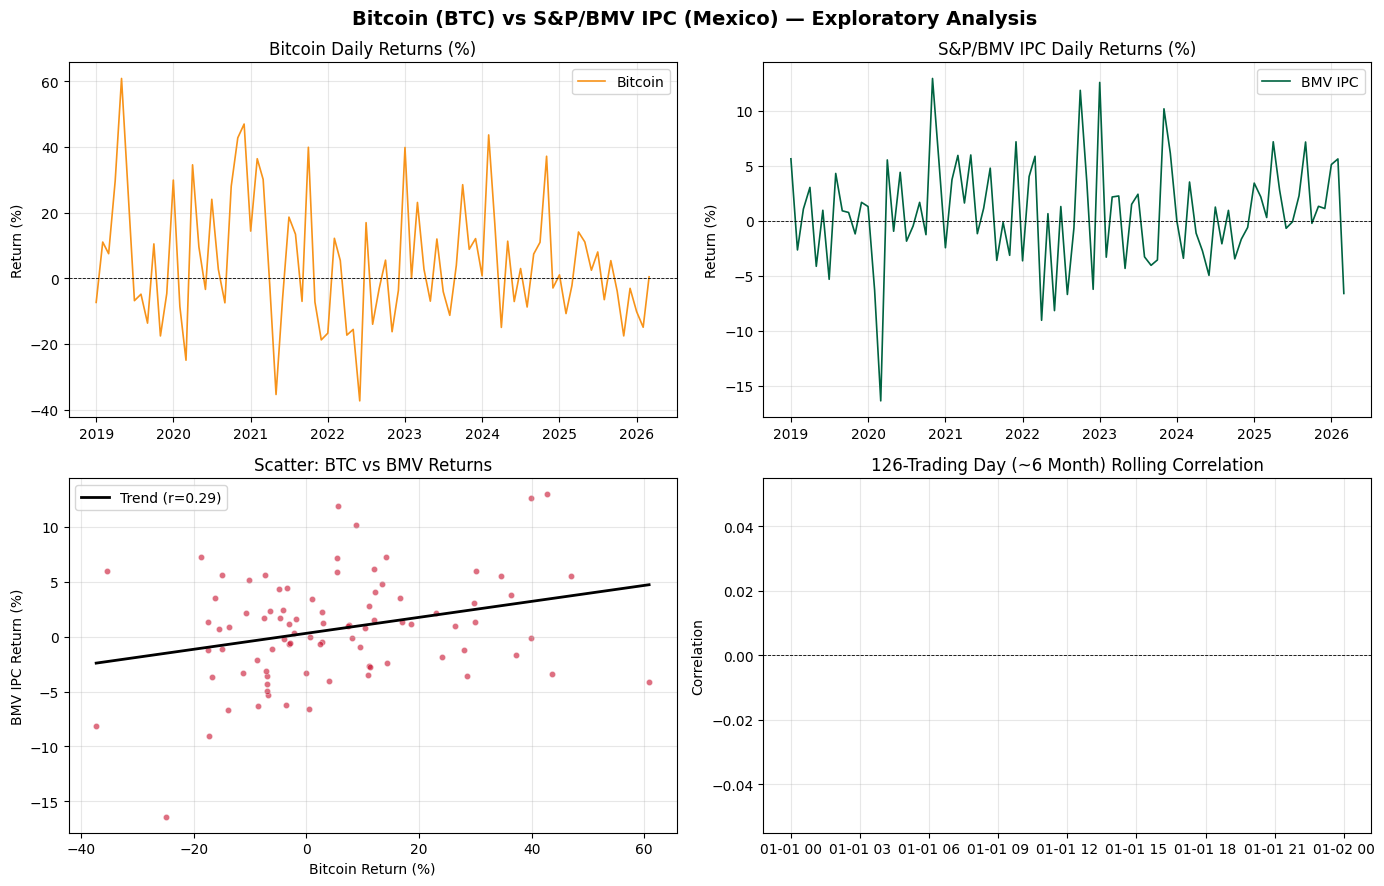


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Bitcoin Return (X̄) = 5.0294%
    Average BMV IPC Return (Ȳ) = 0.6585%

  Step 4 — Slope β
    β = 0.0726
    → For every 1% rise in BTC, BMV changes by ~0.0726%

  Step 5 — Intercept α = 0.002931

  Step 6 — Regression Equation
    BMV_Return = 0.002931 + 0.0726 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0265
    t-statistic = 2.7445
    p-value     = 0.0074
    95% CI      = [0.0200, 0.1253]
    ✔ SIGNIFICANT — Reject H₀ (|t| = 2.74 > 2.0)

  Step 8 — Goodness of Fit
    R² = 0.0814  (8.14% of BMV variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             BMV_Return   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:

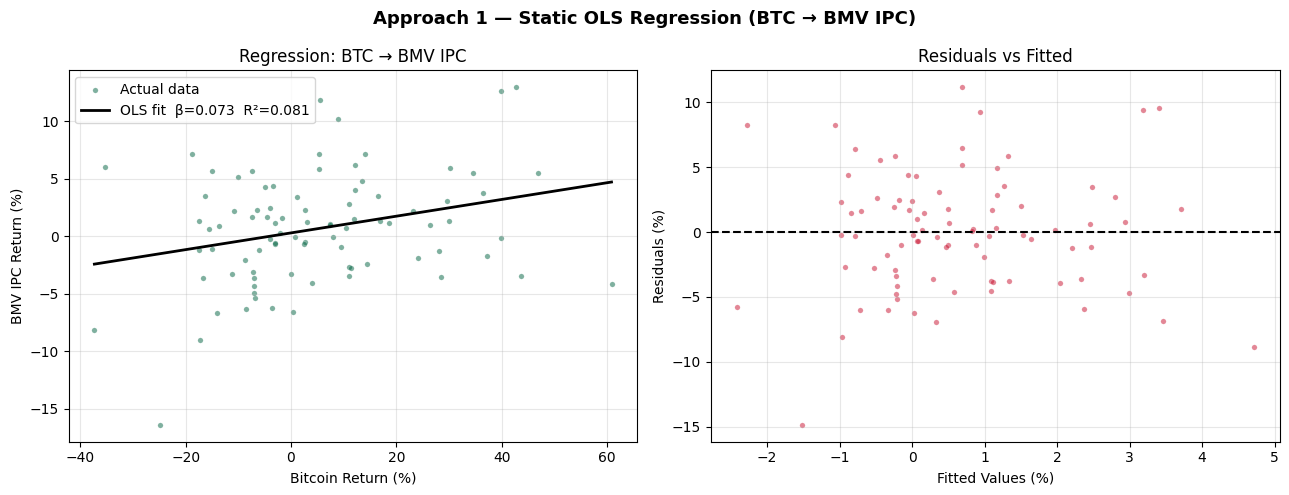


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return                | ADF stat =  -7.390 | p = 0.0000 | ✔ Stationary
    BMV Return                | ADF stat = -10.177 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of BMV Returns
    Lag-1 autocorrelation: -0.1108
    Lag-2 autocorrelation: -0.0334
    ⚠ Notable autocorrelation — lagged term is essential for model validity

  Step 4 & 5 — Building Dynamic Regression Model
    Model: BMV_t = α + β×BTC_t + γ×BMV_(t-1)

    Estimated equation:
    BMV_t = 0.00276 + 0.0724×BTC_t + -0.0672×BMV_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.0724  t=2.697  p=0.0085  ✔ Significant
    Lag effect   (γ): coef=-0.0672  t=-0.630  p=0.5302  ✘ Not significant

    R² (dynamic model) = 0.0919
    Adj. R²            = 0.0700

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause BMV returns
    Sample size: 8

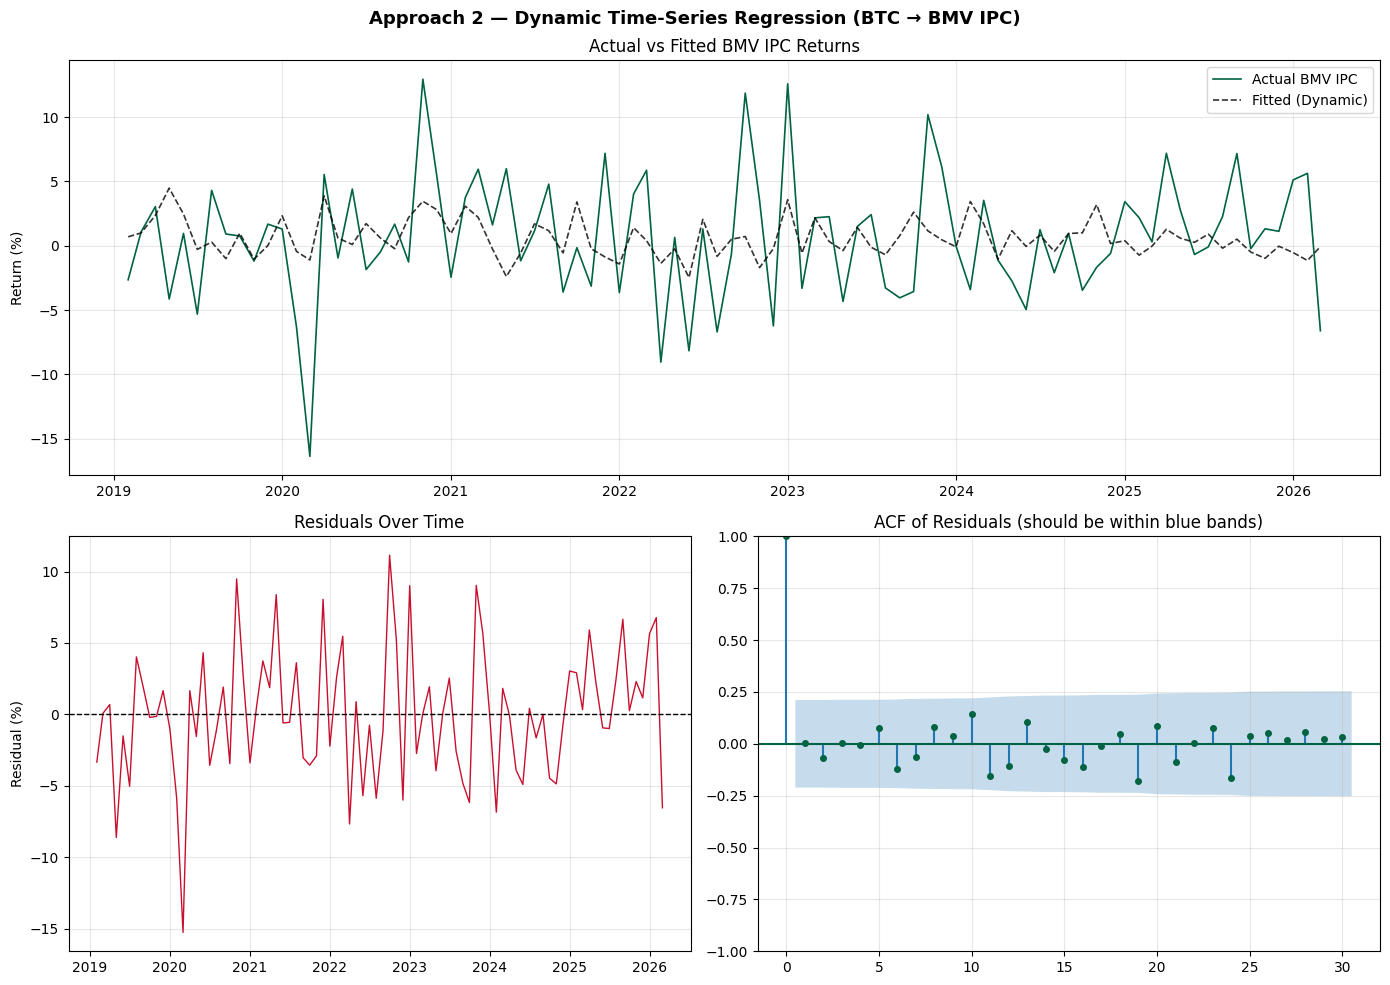


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.0726                    0.0724
Lag Term (γ)                Not included                   -0.0672
p-value (crypto)                  0.0074                    0.0085
R²                                0.0814                    0.0919
Accounts for Memory?                  No                       Yes


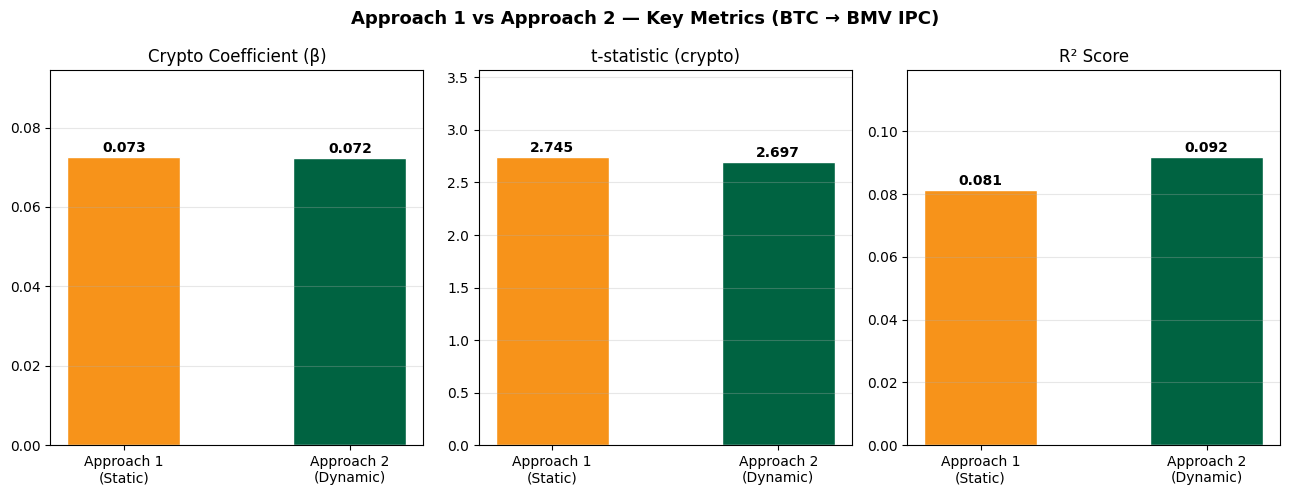


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Bitcoin (BTC) impact on S&P/BMV IPC (Mexico):

  ▸ Approach 1 (Static OLS):
      β = 0.0726 — a 1% BTC change correlates with ~0.073% BMV change
      R² = 0.0814
      Result: SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.0724 — immediate effect after controlling for momentum
      γ = -0.0672 — -6.7% of prior period's BMV return persists
      R² = 0.0919
      Result: SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR MEXICO (S&P/BMV IPC):
  1. Fintech and Remittances: Mexico receives tens of billions in remittances 
     from the US annually. Local fintech unicorns (like Bitso) process a massive 
     chunk of this cross-border capital using crypto rails (Bitcoin and XRP). 
     As these payment rails become deeply integrated into the Mexican financial 
     sector, traditional banking and consumer retail stocks (which make up a large 
     part of the IPC index) bec

In [1]:
# ============================================================
#   BITCOIN (BTC) vs S&P/BMV IPC INDEX (MEXICO) — IMPACT ANALYSIS
# ============================================================

import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both S&P/BMV IPC and Bitcoin CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


BMV_FILE = next((f for f in csv_files if "BMV" in os.path.basename(f).upper() or "IPC" in os.path.basename(f).upper() or "MEXICO" in os.path.basename(f).upper()), None)
BTC_FILE = next((f for f in csv_files if "Bitcoin" in os.path.basename(f) or "bitcoin" in os.path.basename(f)
                                         or "crypto" in os.path.basename(f) or "BTC" in os.path.basename(f)), None)

if BMV_FILE is None or BTC_FILE is None:
    remaining = [f for f in csv_files if f not in (BMV_FILE, BTC_FILE)]
    if BMV_FILE is None and remaining:
        BMV_FILE = remaining.pop(0)
    if BTC_FILE is None and remaining:
        BTC_FILE = remaining.pop(0)

if BMV_FILE is None or BTC_FILE is None:
    raise FileNotFoundError(
        "Could not identify both BMV IPC and Bitcoin CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'BMV'/'IPC' and 'Bitcoin'/'crypto'."
    )

print("\n" + "=" * 65)
print("  BITCOIN (BTC) vs S&P/BMV IPC (MEXICO) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    S&P/BMV IPC : {BMV_FILE}")
print(f"    Bitcoin     : {BTC_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)

    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

btc = load_and_clean(BTC_FILE, "BTC_Return")
bmv = load_and_clean(BMV_FILE, "BMV_Return")


data = pd.merge(btc, bmv, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "BMV_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "BMV_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["BMV_Return"])
print(f"\n  Pearson Correlation (Bitcoin vs S&P/BMV IPC): {corr:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Bitcoin (BTC) vs S&P/BMV IPC (Mexico) — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100, color="#F7931A", label="Bitcoin", linewidth=1.2) # Bitcoin Orange
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["BMV_Return"] * 100, color="#006341", label="BMV IPC", linewidth=1.2) # Mexican Green
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("S&P/BMV IPC Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["BMV_Return"] * 100,
           alpha=0.6, color="#C8102E", edgecolors="white", linewidth=0.4, s=20) # Mexican Red
m, b = np.polyfit(data["BTC_Return"], data["BMV_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="black", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("BMV IPC Return (%)")
ax.set_title("Scatter: BTC vs BMV Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["BTC_Return"].rolling(126).corr(data["BMV_Return"])
ax.plot(data["Date"], roll_corr, color="#006341", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["BMV_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Bitcoin Return (X̄) = {x_mean*100:.4f}%")
print(f"    Average BMV IPC Return (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, BMV changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    BMV_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["BTC_Return"]
t_stat    = ols_model.tvalues["BTC_Return"]
p_value   = ols_model.pvalues["BTC_Return"]
ci        = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of BMV variation explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (BTC → BMV IPC)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#006341", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="black", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("BMV IPC Return (%)")
ax.set_title("Regression: BTC → BMV IPC")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#C8102E", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["BMV_Return"], "BMV Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of BMV Returns")
lag1_autocorr = data["BMV_Return"].autocorr(lag=1)
lag2_autocorr = data["BMV_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: BMV_t = α + β×BTC_t + γ×BMV_(t-1)")

data_dyn = data.copy()
data_dyn["BMV_Lag1"] = data_dyn["BMV_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["BMV_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "BMV_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["BMV_Lag1"]

print(f"\n    Estimated equation:")
print(f"    BMV_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t + {gamma_dyn:.4f}×BMV_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "BMV_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause BMV returns")
granger_data = data[["BMV_Return", "BTC_Return"]].dropna()
max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(5, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (BTC → BMV IPC)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#006341", linewidth=1.2, label="Actual BMV IPC")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted BMV IPC Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#C8102E", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#006341", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_value:.4f}", f"{dyn_model.pvalues['BTC_Return']:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (BTC → BMV IPC)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#F7931A", "#006341"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if dyn_model.pvalues['BTC_Return'] < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Bitcoin (BTC) impact on S&P/BMV IPC (Mexico):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC change correlates with ~{beta:.3f}% BMV change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's BMV return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR MEXICO (S&P/BMV IPC):
  1. Fintech and Remittances: Mexico receives tens of billions in remittances
     from the US annually. Local fintech unicorns (like Bitso) process a massive
     chunk of this cross-border capital using crypto rails (Bitcoin and XRP).
     As these payment rails become deeply integrated into the Mexican financial
     sector, traditional banking and consumer retail stocks (which make up a large
     part of the IPC index) become sensitive to crypto adoption and liquidity.
  2. The US "Risk-On" Echo: Mexico's economy is profoundly tied to the United
     States via trade (USMCA). When the US Federal Reserve cuts interest rates
     or injects liquidity, capital flows violently into both US tech stocks/crypto
     and emerging market equities like Mexico's. A significant correlation here
     often represents a shared response to US macroeconomic policy.
  3. Real Utility vs Speculation: Unlike mature markets where correlation is
     driven by ETF speculation, Mexico's correlation has a strong root in actual
     utility—using decentralized networks to bypass legacy bank fees. As local
     financial groups adapt to this disruption, their market valuations naturally
     intertwine with the broader success of the digital asset ecosystem.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)